#  Прогнозирование заказов такси

Компания собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Нужно:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.

## Подготовка

In [1]:
# Импорт стандартных библиотек
import pandas as pd
import numpy as np

# Импорт библиотек для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# Импорт библиотек для машинного обучения и обработки данных
from sklearn.model_selection import train_test_split,  RandomizedSearchCV, cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import  mean_absolute_error,  mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.dummy import  DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
#выведем первые 5 строк полученного датафрейма
data.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


Сделаем ресемплирование по часу, так как дальше нас интересует прогноз на следующий час

In [5]:
#ресемплирование 
data_new = data.resample('1H').sum()

In [6]:
#проверим
data_new.head(10)

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43
2018-03-01 05:00:00,6
2018-03-01 06:00:00,12
2018-03-01 07:00:00,15
2018-03-01 08:00:00,34


Далее проанализируем наши полученные данные. Посмотрим на распределение и сезонные тренды данных.

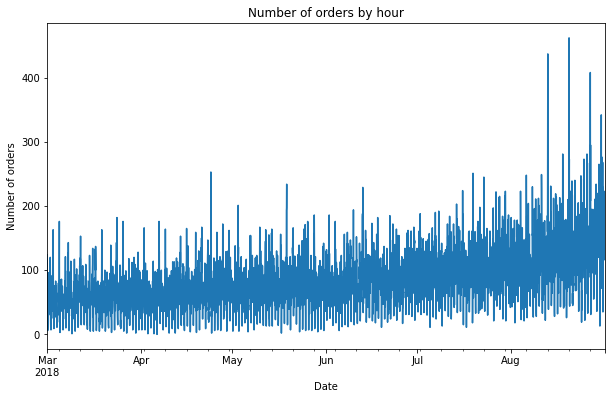

In [7]:
# построим график распределения заказов
data_new['num_orders'].plot(figsize=(10,6))
plt.title('Number of orders by hour')
plt.xlabel('Date')
plt.ylabel('Number of orders')
plt.show()

Согласно графику, видно небольшой тренд увеличения заказов в летний период

In [8]:
# Проверим минимальную и максимальную дату в данных
min_date = data_new.index.min()
max_date = data_new.index.max()

In [9]:
min_date

Timestamp('2018-03-01 00:00:00', freq='H')

In [10]:
max_date

Timestamp('2018-08-31 23:00:00', freq='H')

Данные в датасете представлены в с 1 марта 2018 до 31 августа 2018

Далее проведем разложение на тренды и сезонность, используя метод seasonal_decompose

In [11]:
#разложим наши данные
decomposed = seasonal_decompose(data_new)

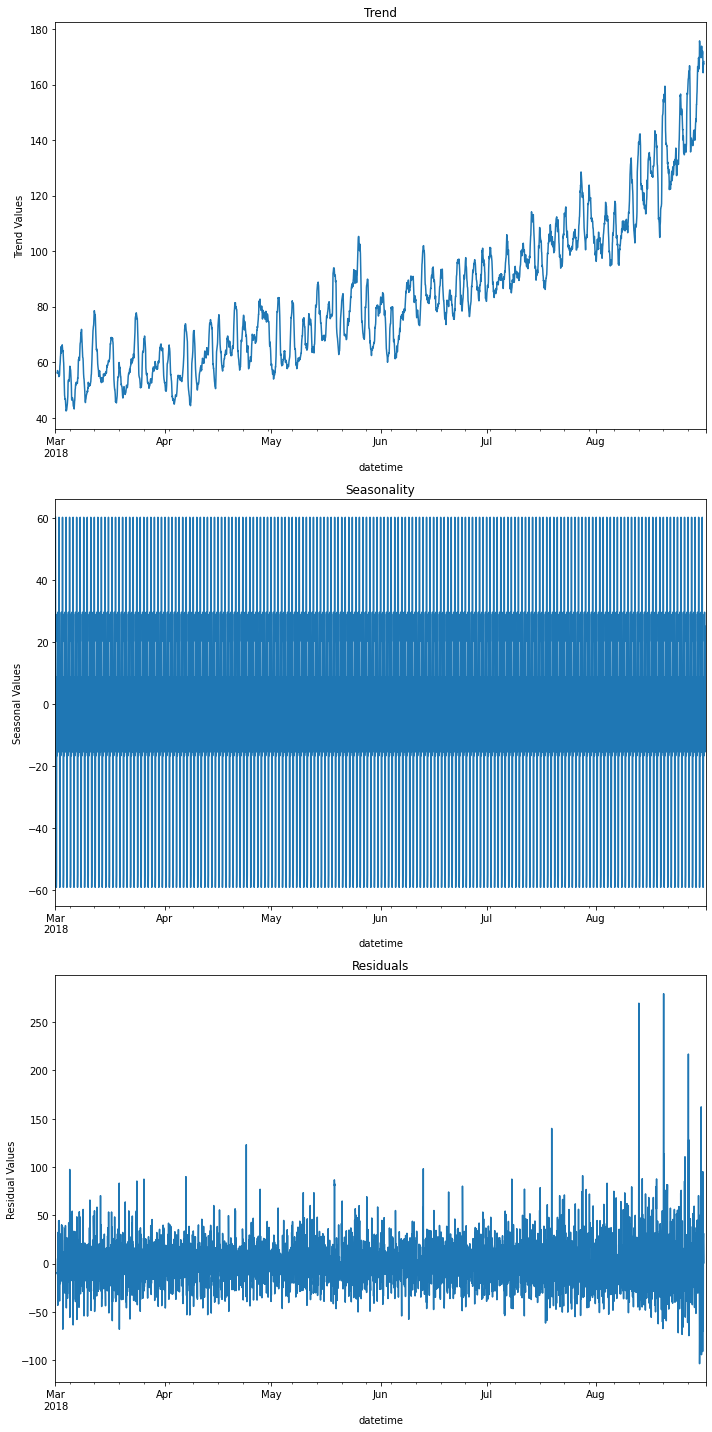

In [12]:
plt.figure(figsize=(10,20))

# Тренд
plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.title('Trend')
plt.ylabel('Trend Values') 

# Сезонность
plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca())
plt.title('Seasonality')
plt.ylabel('Seasonal Values')  

# Остатки
plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.title('Residuals')
plt.ylabel('Residual Values') 

plt.tight_layout()

Тренд показывает долгосрочное изменение уровня данных. Он сглаживает краткосрочные колебания и выделяет общую направленность данных во времени. График тренда у нас идет вверх, что указывает на рост временного ряда (постепенного увеличения количества заказов с марта по конец августа 2018 г).
График сезонности отражает повторяющиеся краткосрочные колебания, которые происходят через регулярные интервалы времени (например, ежемесячно, ежегодно, еженедельно). Если бы данные имели выраженную сезонность, мы бы увидели циклы на графике (например, пики в определенные месяцы года или дни недели). Тут мы видим почти сплошную закрашенную полосу без четких повторяющихся колебаний, что говорит нам о том, что сезонные колебания не выражены или отсутствуют. Также причинами такой ситуации могут быть неудачный выбор параметров для разложения, шум в данных или слишком малый рассматриваемый временной отрезок.
Остатки (residuals) — это данные, из которых были исключены тренд и сезонность. Они показывают случайные, нерегулярные колебания, которые не объясняются долгосрочными трендами или сезонными циклами.

Далее изучим сезонность на отрезке с 31.07.2018 до 31.08.2018

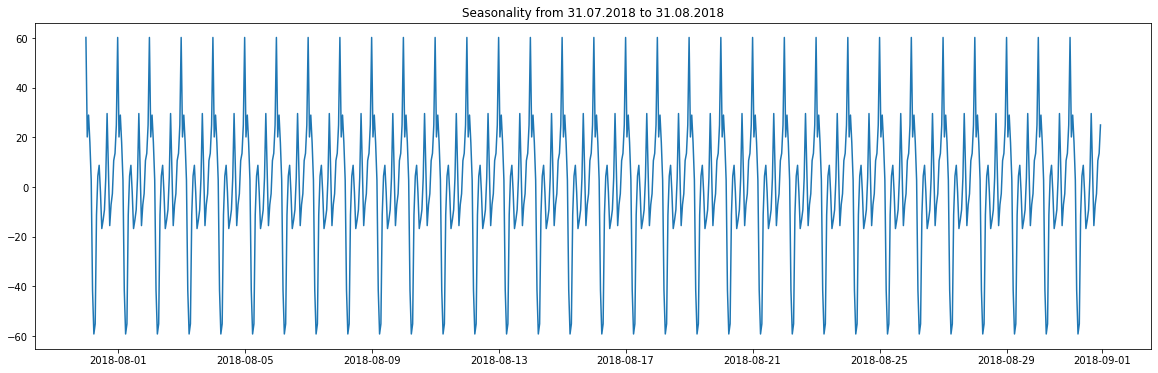

In [13]:
# Изучим сезонность на подотрезке времени
seasonal_subset = decomposed.seasonal['2018-07-31':'2018-08-31']

# Построим график сезонности для этого подотрезка
plt.figure(figsize=(20, 6))
plt.plot(seasonal_subset)
plt.title('Seasonality from 31.07.2018 to 31.08.2018')
plt.show()

На графике сезонности для подотрезка времени с 31 июля по 31 августа 2018 года наблюдаются регулярные и цикличные колебания, напоминающие волну (или кардиограмму), которая повторяется каждый день. Каждые сутки мы видим повторяющийся паттерн — в течение дня значения сезонности сначала увеличиваются, затем резко падают, затем вновь поднимаются. Это явление указывает на ярко выраженную ежедневную циклическую сезонность. Колебания достаточно резкие, с изменениями от высоких положительных значений до отрицательных. Например, начинается с пика около 60, затем наблюдается падение до -60 и снова возврат к положительным значениям к следующему дню. Это говорит о том, что сезонные изменения в данном временном ряде имеют существенную амплитуду. Паттерн повторяется практически одинаково каждый день, что говорит о том, что данные подвержены сильным дневным циклам. Это может свидетельствовать о том, что временной ряд зависит от процессов, которые происходят на регулярной основе в течение каждого дня (например, смена активности в зависимости от времени суток).

Далее подготовим наши признаки

Создадим новые признаки, такие как:
Лаговые признаки (lag_features) — число заказов за предыдущие часы.
Скользящее среднее (rolling_mean) за несколько часов.

Признаки "день недели" и "час дня" и тд играют важную роль в задачах временных рядов, особенно при прогнозировании, потому что они помогают модели учитывать сезонные закономерности и циклы, которые могут влиять на целевую переменную (в данном случае, количество заказов такси). 

In [14]:
def make_features(data_new, max_lag, rolling_mean_size):
    # Создаем копию исходного датафрейма с тем же названием
    data_new = data_new.copy()
    
    # Добавляем признаки: месяц, день, день недели и час
    data_new['month'] = data_new.index.month
    data_new['day'] = data_new.index.day
    data_new['dayofweek'] = data_new.index.dayofweek
    data_new['hour'] = data_new.index.hour
    
    # Генерируем лаги
    for lag in range(1, max_lag + 1):
        data_new[f'lag_{lag}'] = data_new['num_orders'].shift(lag)
        
    # Создаем скользящее среднее
    data_new['rolling_mean'] = data_new['num_orders'].shift().rolling(window=rolling_mean_size).mean()
    
    # Возвращаем новый датафрейм
    return data_new

В нашем случае, так как сезонность повторяется ежедневно (как было показано ранее), длина окна должна быть кратной дню. Поэтому сделаем 24 часа для почасовых данных.

In [23]:
data_new = make_features(data_new, max_lag=24, rolling_mean_size=24)

In [24]:
data_new.head()

,num_orders,month,day,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5,...,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-01 00:00:00,124,3,1,3,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 01:00:00,85,3,1,3,1,124.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 02:00:00,71,3,1,3,2,85.0,124.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 03:00:00,66,3,1,3,3,71.0,85.0,124.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 04:00:00,43,3,1,3,4,66.0,71.0,85.0,124.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
#проверим наличие дубликатов
data_new.duplicated().sum()

0

In [26]:
# Удалим строки с пропусками (созданные лагами)
data_new = data_new.dropna()

In [27]:
data_new.head()

,num_orders,month,day,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5,...,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-02 00:00:00,90,3,2,4,0,58.0,113.0,66.0,61.0,45.0,...,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,124.0,56.833333
2018-03-02 01:00:00,120,3,2,4,1,90.0,58.0,113.0,66.0,61.0,...,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,55.416667
2018-03-02 02:00:00,75,3,2,4,2,120.0,90.0,58.0,113.0,66.0,...,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,56.875000
2018-03-02 03:00:00,64,3,2,4,3,75.0,120.0,90.0,58.0,113.0,...,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,57.041667
2018-03-02 04:00:00,20,3,2,4,4,64.0,75.0,120.0,90.0,58.0,...,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,56.958333


## Анализ

Проанализируем полученные данные и зависимости

In [28]:
data_new.describe()

,num_orders,month,day,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5,...,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean
count,4392.000000,4392.000000,4392.000000,4392.000000,4392.000000,4392.000000,4392.000000,4392.000000,4392.000000,4392.000000,...,4392.000000,4392.000000,4392.000000,4392.000000,4392.000000,4392.000000,4392.000000,4392.000000,4392.000000,4392.000000
mean,84.573543,5.519126,15.918033,3.005464,11.500000,84.540073,84.515027,84.493852,84.472678,84.451958,...,84.152322,84.145264,84.140027,84.123634,84.072404,84.064891,84.028689,84.003871,83.969262,84.257153
std,45.050123,1.707912,8.811011,1.996117,6.922975,45.015225,44.968748,44.955561,44.944716,44.941932,...,44.723919,44.732387,44.739487,44.754926,44.673101,44.673365,44.619468,44.588590,44.498432,26.308289
min,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,42.375000
25%,54.000000,4.000000,8.000000,1.000000,5.750000,54.000000,54.000000,54.000000,54.000000,54.000000,...,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,63.666667
50%,78.000000,6.000000,16.000000,3.000000,11.500000,78.000000,78.000000,78.000000,78.000000,78.000000,...,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,79.708333
75%,108.000000,7.000000,24.000000,5.000000,17.250000,108.000000,108.000000,107.250000,107.000000,107.000000,...,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,99.802083
max,462.000000,8.000000,31.000000,6.000000,23.000000,462.000000,462.000000,462.000000,462.000000,462.000000,...,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,176.916667


В среднем на каждый час приходится ок 84 заказа с стандартным отклонением 45 заказов. Количество заказов варьируется от 0 до 462 заказов в час. В 75% случаев число заказов составляет до 107 в час.

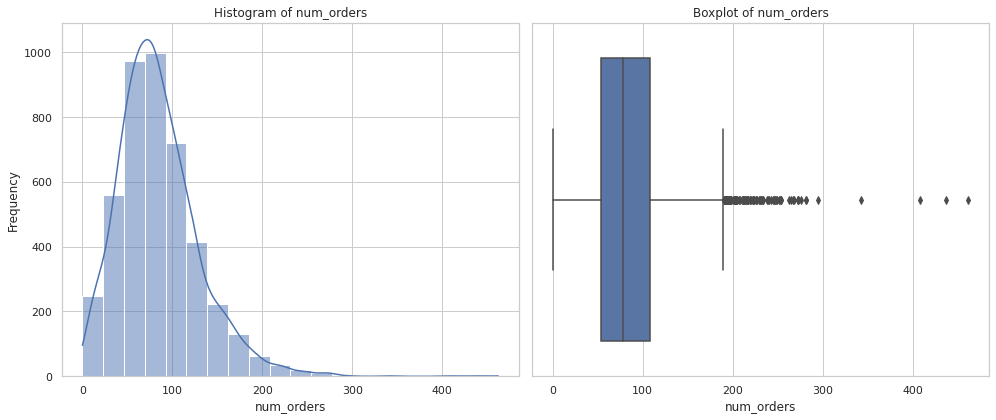

In [29]:
# установим стиль графиков
sns.set(style="whitegrid")
# создадим фигуру и оси для графиков
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# построим гистограмму
sns.histplot(data_new['num_orders'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Histogram of num_orders')
axes[0].set_xlabel('num_orders')
axes[0].set_ylabel('Frequency')
# построим боксплот
sns.boxplot(x=data_new['num_orders'], ax=axes[1])
axes[1].set_title('Boxplot of num_orders')
axes[1].set_xlabel('num_orders')

# выведем графики на экран
plt.tight_layout()
plt.show()

Максимум в час 462 заказа, что значительно выше среднего значения (84.4). Это может указывать на наличие аномально высоких значений (выбросов), но пока не будем их удалять. Минимум - 0, что может быть допустимым значением, если в некоторые моменты заказов действительно не было.
Стандартное отклонение 45, что указывает на высокую вариативность значений

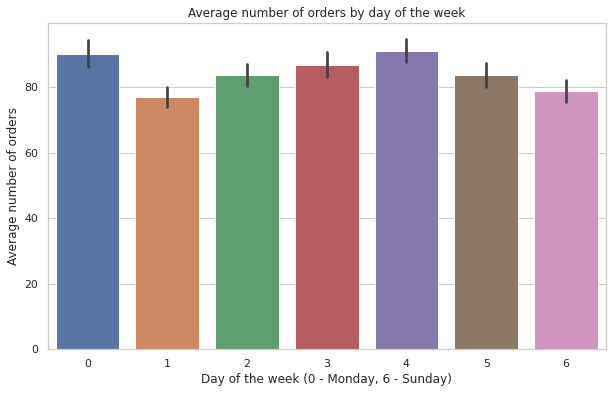

In [30]:
# Среднее количество заказов по дням недели
plt.figure(figsize=(10, 6))
sns.barplot(x='dayofweek', y='num_orders', data=data_new)
plt.title('Average number of orders by day of the week')
plt.xlabel('Day of the week (0 - Monday, 6 - Sunday)')
plt.ylabel('Average number of orders')
plt.show()

Согласно графику, наибольшее количество заказов наблюдается в понедельник и пятницу, что может указывать на повышенный спрос в начале недели и в преддверии выходных. В то же время, наименьшее среднее количество заказов зафиксировано во вторник и воскресенье, что может быть связано с низкой активностью пользователей такси в эти дни.
Важно отметить, что разница между средними значениями заказов по дням недели не столь велика. Это может говорить о том, что в целом спрос на такси относительно стабилен в течение недели, и различия не так критичны, особенно если учитывать возможные колебания или ошибки в данных.

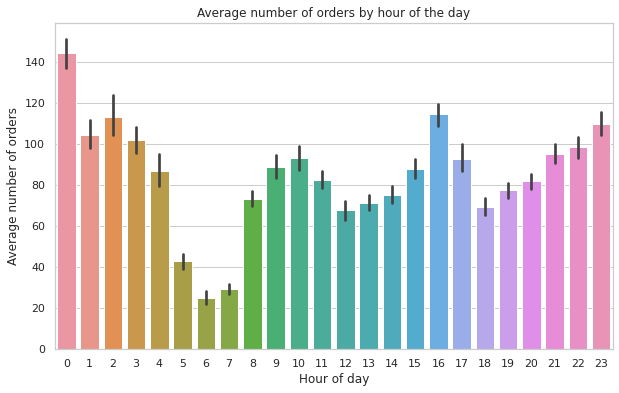

In [31]:
# Среднее количество заказов по часам дня
plt.figure(figsize=(10, 6))
sns.barplot(x='hour', y='num_orders', data=data_new)
plt.title('Average number of orders by hour of the day')
plt.xlabel('Hour of day')
plt.ylabel('Average number of orders')
plt.show()

Согласно графику, наибольшее количество заказов такси фиксируется в ночные часы с 12 до 3 ночи, а также в промежутках между 15-17 часами и 21-13 часами. Это может быть связано с тем, что в ночное время общественный транспорт не функционирует, что повышает спрос на такси среди людей, возвращающихся домой или ночующих в городе.
Интересно также отметить, что минимальное количество заказов наблюдается в интервале с 5 до 7 утра. 

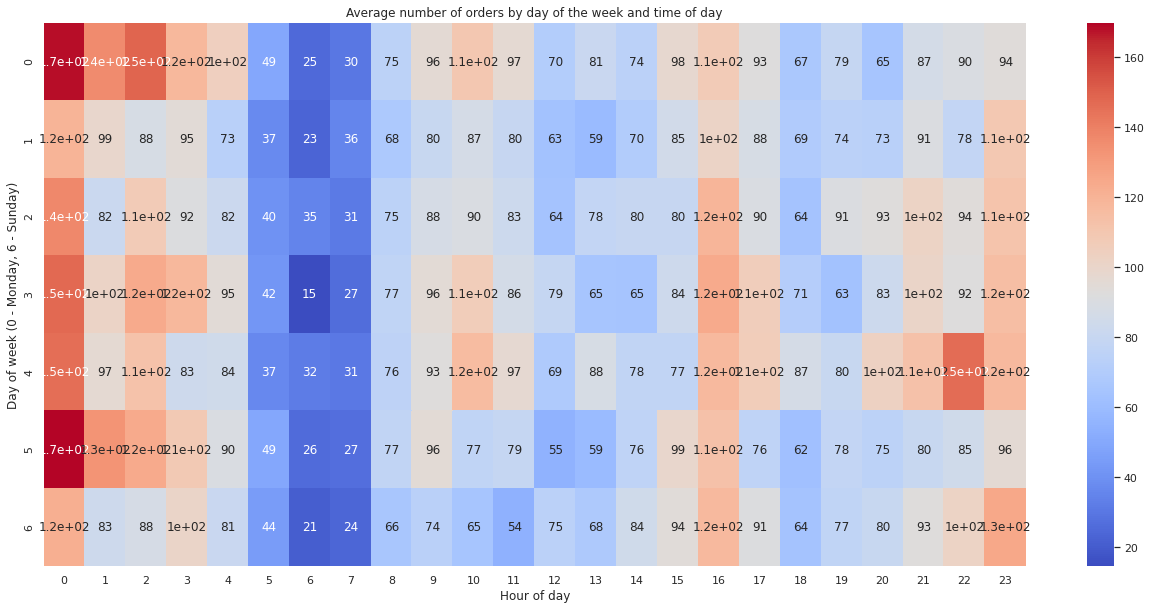

In [32]:
# Создание сводной таблицы
pivot_table = data_new.pivot_table(index='dayofweek', columns='hour', values='num_orders', aggfunc='mean')

# Визуализация в виде тепловой карты
plt.figure(figsize=(22, 10))
sns.heatmap(pivot_table, cmap='coolwarm', annot=True)
plt.title('Average number of orders by day of the week and time of day')
plt.xlabel('Hour of day')
plt.ylabel('Day of week (0 - Monday, 6 - Sunday)')
plt.show()

## Обучение

In [33]:
# Разделение данных на тренировочную и тестовую выборки (90% и 10%)
train, test = train_test_split(data_new, shuffle=False, test_size=0.1)

In [34]:
# определим признаки и целевую переменную
X_train = train.drop(columns=['num_orders'])
y_train = train['num_orders']
X_test = test.drop(columns=['num_orders'])
y_test = test['num_orders'].dropna() 
X_train.shape, X_test.shape

((3952, 29), (440, 29))

In [35]:
# Признаки для подготовки
num_columns = ['month', 'day', 'dayofweek', 'hour', 'lag_1', 'lag_2', 'lag_3','lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'lag_13', 'lag_14', 'lag_15','lag_16', 'lag_17', 'lag_18', 'lag_19', 'lag_20', 'lag_21','lag_22', 'lag_23', 'lag_24', 'rolling_mean']

# Создаем общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('num', MinMaxScaler(), num_columns)],
    remainder='passthrough'
)

In [36]:
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('model', RandomForestRegressor(random_state=42)) 
])

# параметры для RandomizedSearchCV
param_grid = [
    {
        'model': [RandomForestRegressor(random_state=42)],
        'model__n_estimators': [100, 300, 500],
        'model__max_depth': [None, 10, 15],
        'model__max_features': [3, 4, 5],
        'model__min_samples_leaf': [1, 2, 3],
        'model__min_samples_split': [2, 3, 4],
        'model__max_samples': [0.5, 0.75]
    },
    {
        'model': [LGBMRegressor(random_state=42)],
        'model__n_estimators': [100, 300, 500],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [None, 6, 10],
        'model__num_leaves': [31, 63],
        'model__min_data_in_leaf': [20, 50]
    },
    {
        'model': [CatBoostRegressor(random_state=42, silent=True)],
        'model__iterations': [100, 300, 500], 
        'model__learning_rate': [0.08, 0.09, 0.1, 0.11, 0.12],
        'model__depth': [5, 6, 7, 8, 10],
        'model__l2_leaf_reg': [3, 5],
        'model__bagging_temperature': [1, 2],
        'model__border_count': [32, 64]
    },
    {
        'model': [XGBRegressor(random_state=42)],
        'model__n_estimators': [450, 475, 500, 525, 550],
        'model__learning_rate': [0.08, 0.09, 0.1, 0.11, 0.12],
        'model__max_depth': [None, 5, 6, 7, 8],
        'model__subsample': [0.75, 0.77, 0.8, 0.82, 0.85],
        'model__colsample_bytree': [0.55, 0.58, 0.6, 0.62, 0.65]
    },
    {
        'model': [LinearRegression()],
        'model__fit_intercept': [True, False]
    }
]

In [37]:
# Инициализация TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Инициализация RandomizedSearchCV с TimeSeriesSplit
random_search = RandomizedSearchCV(
    pipe_final,
    param_distributions=param_grid,
    cv=tscv,  
    scoring='neg_root_mean_squared_error',  
    n_jobs=-1,
    random_state=42
)

# Обучение модели
random_search.fit(X_train, y_train)


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('num',
                                                                               MinMaxScaler(),
                                                                               ['month',
                                                                                'day',
                                                                                'dayofweek',
                                                                                'hour',
                                                                                'lag_1',
                                                                                'lag_2',
                                      

In [40]:
best_model = random_search.best_estimator_

In [41]:
best_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', MinMaxScaler(),
                                                  ['month', 'day', 'dayofweek',
                                                   'hour', 'lag_1', 'lag_2',
                                                   'lag_3', 'lag_4', 'lag_5',
                                                   'lag_6', 'lag_7', 'lag_8',
                                                   'lag_9', 'lag_10', 'lag_11',
                                                   'lag_12', 'lag_13', 'lag_14',
                                                   'lag_15', 'lag_16', 'lag_17',
                                                   'lag_18', 'lag_19', 'lag_20',
                                                   'lag_21', 'lag_22', 'lag_23',
                                                   'lag_24',
                                                   'roll

In [42]:
best_model.named_steps['model']

In [43]:
random_search.best_params_

{'model__learning_rate': 0.08,
 'model__l2_leaf_reg': 5,
 'model__iterations': 500,
 'model__depth': 5,
 'model__border_count': 64,
 'model__bagging_temperature': 1,
 'model': <catboost.core.CatBoostRegressor at 0x7fd7a732aac0>}

В результате применения метода случайного поиска (RandomizedSearchCV) была выявлена оптимальная модель для задачи регрессии - CatBoostRegressor с параметрами: {'model__learning_rate': 0.08, 'model__l2_leaf_reg': 5, 'model__iterations': 500, 'model__depth': 5, 'model__border_count': 64, 'model__bagging_temperature': 1}

In [44]:
best_neg_mse = random_search.best_score_

# Вычисляем RMSE из отрицательной метрики MSE
best_rmse = np.sqrt(abs(best_neg_mse))
print(f'Лучший RMSE на обучающей выборке: {best_rmse:.2f}')

Лучший RMSE на обучающей выборке: 4.93


RMSE на обучающей выборке - 4.93

## Тестирование

Оценим модель на тестовых данных

In [45]:
# оценим лучшую модель на тестовой выборке
y_test_pred = random_search.predict(X_test)
rmse = mean_squared_error(y_test, y_test_pred, squared=False)
print(f'RMSE на тестовой выборке: {rmse:.2f}')

RMSE на тестовой выборке: 38.99


Далее сравним нашу лучшую модель с константной моделью

In [46]:
#инициализируем DummyRegressor со стратегией 'mean'
dummy_model = DummyRegressor(strategy='mean')
dummy_model.fit(X_train, y_train)

#предскажем константную модель на тестовых данных
y_dummy_pred = dummy_model.predict(X_test)

#оценим качество константной модели
print(f'Метрика MSE на тестовой выборке: {mean_squared_error(y_test, y_dummy_pred )}')
print(f'Метрика RSME на тестовой выборке: {np.sqrt(mean_squared_error(y_test, y_dummy_pred ))}')

Метрика MSE на тестовой выборке: 7172.003630090344
Метрика RSME на тестовой выборке: 84.68768287118466


Наша лучшая модель значительно превосходит константную модель, что подтверждает, что все усилия по созданию новых признаков, тюнингу и кросс-валидации оправданы. Это также подтверждает, что наша модель вносит существенный вклад в улучшение качества предсказаний по сравнению с простым подходом.

Далее проведем анализ остатков.

In [47]:
# Предсказанные значения на тестовой выборке
y_test_pred = random_search.best_estimator_.predict(X_test)
residuals = y_test - y_test_pred

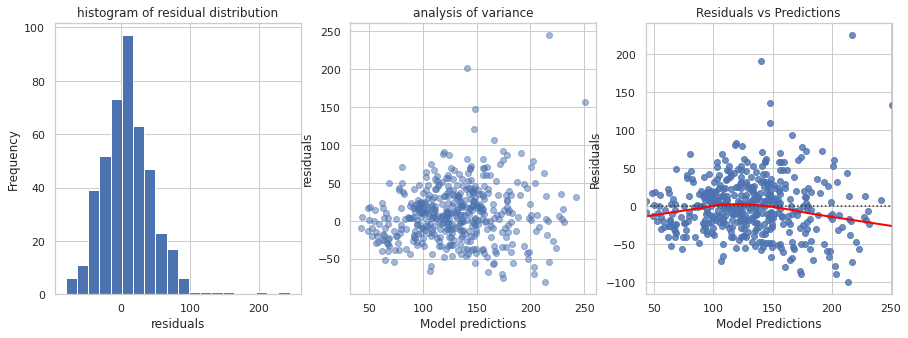

In [48]:
#Построим графики по количественным признакам - гистограмму частотности
#распределения и диаграмму рассеяния
fig, axes = plt.subplots(nrows = 1, ncols= 3, figsize = (15, 5))

axes[0].hist(residuals, bins = 20)
axes[0].set_title('histogram of residual distribution')
axes[0].set_xlabel('residuals')
axes[0].set_ylabel('Frequency')

axes[1].scatter(y_test_pred, residuals, alpha = 0.5)
axes[1].set_xlabel('Model predictions')
axes[1].set_ylabel('residuals')
axes[1].set_title('analysis of variance')

# sns.residplot для оценки распределения остатков 
sns.residplot(x=y_test_pred, y=residuals, lowess=True, ax=axes[2], line_kws={'color': 'red', 'lw': 2})
axes[2].set_title('Residuals vs Predictions')
axes[2].set_xlabel('Model Predictions')
axes[2].set_ylabel('Residuals')

plt.show()

Остатки модели не только показывают разницу между предсказанным и истинным значениями. Они также отражают закономерности, которые позволяют судить о качестве модели. Анализ остатков проверяет не решения модели, а то, насколько хорошо она замечает взаимосвязи между признаками. Если она не справляется с этим, то уже не важно, близки ли её предсказания к исходным значениям. Модель будет работать нестабильно.

Если посмотрим на график распределения остатков (график слева), то он выгядит чуть смещенным влево. Возможно, это из-за оставленных выбросов.
Если посмотрим на диаграмму рассеяния (2 графика справа) остатков в зависимости от прогнозных значений модели, то отметим, что линия, полученная с помощью lowess, с небольшим искривлением, это указывает на то, что возможны небольшие отклонения в зависимости от предсказанных значений. Небольшое искривление линии может свидетельствовать о возможных нелинейных отношениях, которые модель не полностью улавливает. В таком случае, модель может слегка недооценивать или переоценивать значения в определенных диапазонах предсказаний.
Можно:
Найти и добавить в модель дополнительные признаки. Скорее всего, на этапе сбора данных не учли какие-то признаки.
Либо решить возможно, с аномальными значениями

Визуализируем предсказанные значения модели и сравним их с фактическими для лучшего понимания того, где модель ошибается:

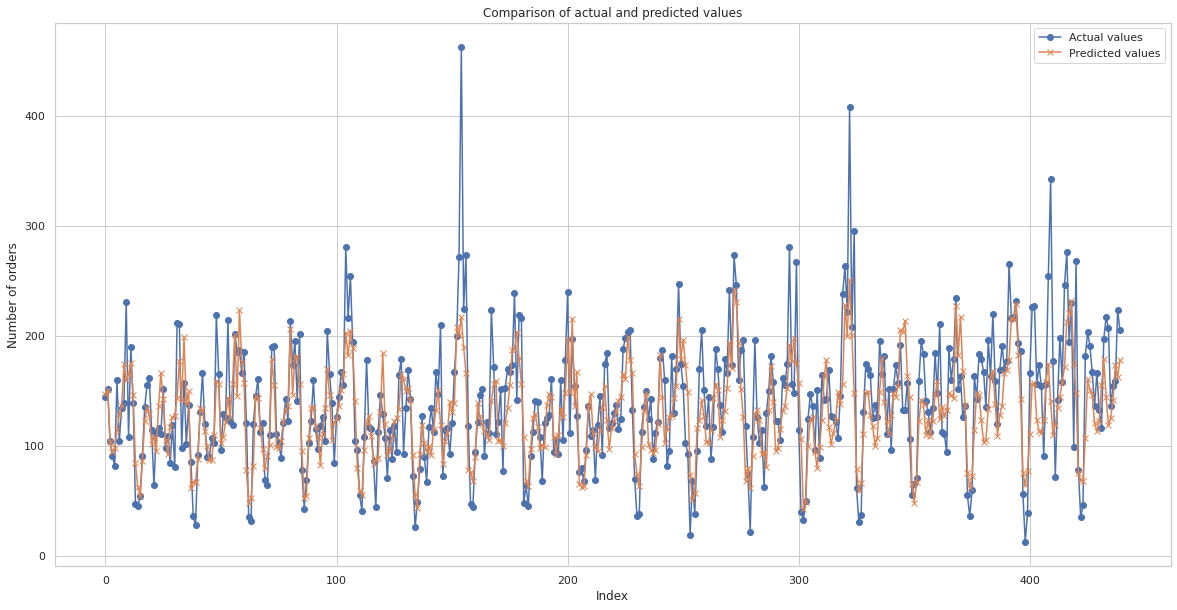

In [49]:
plt.figure(figsize=(20,10))
plt.plot(y_test.values, label='Actual values', marker='o')
plt.plot(y_test_pred, label='Predicted values', marker='x')
plt.xlabel('Index')
plt.ylabel('Number of orders')
plt.title('Comparison of actual and predicted values')
plt.legend()
plt.show()

**Вывод**

В процессе анализа данных о количестве заказов была выполнена предварительная обработка временных рядов, включая ресемплирование по часу для получения агрегированных значений. Данные были исследованы на наличие дубликатов и пропусков, после чего были созданы новые признаки, такие как лаговые значения и скользящее среднее, а также временные характеристики, такие как месяц, день, день недели и час. Эти признаки были использованы для построения модели предсказания количества заказов с применением различных алгоритмов, включая RandomForest, LightGBM, CatBoost и XGBoost. В результате применения метода случайного поиска (RandomizedSearchCV) была выявлена оптимальная модель для задачи регрессии: CatBoostRegressor с параметрами {'model__learning_rate': 0.08, 'model__l2_leaf_reg': 5, 'model__iterations': 500, 'model__depth': 5, 'model__border_count': 64, 'model__bagging_temperature': 1} и с минимальным значением RMSE 4.93 на тренировочной выборке, в то время как на тестовой выборке RMSE составил 38.99. Модель показала значительное превосходство по сравнению с константной моделью, что подтверждает эффективность подхода к созданию признаков и проведению кросс-валидации. Визуализация остатков и предсказанных значений позволила проанализировать качество модели и выявить области, где модель ошибается. Результаты подтверждают, что построенная модель способна значительно улучшить точность предсказаний по сравнению с простыми методами.